<a href="https://colab.research.google.com/github/Sripriyaaa777/Qiskit_workshop/blob/main/Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Step 1: Install Libraries & Import Everything ---

# Install all required libraries
!pip install -q qiskit
!pip install -q qiskit-machine-learning
!pip install -q qiskit-algorithms
!pip install -q scikit-learn
!pip install -q matplotlib

# Import libraries for data and plotting
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import Qiskit libraries for the QNN
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.utils.loss_functions import CrossEntropyLoss

# Set a random seed so we can get reproducible results
algorithm_globals.random_seed = 42

print("Step 1 Complete: All libraries installed and imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 7.8 MB/s eta 0:00:00
Step 1 Complete: All libraries installed and imported.


Our Training Data:


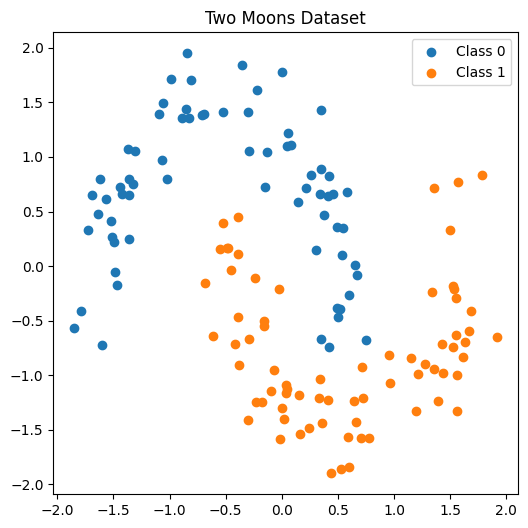

Data ready: 140 training samples, 60 test samples.


In [ ]:
# --- Step 2: Load and Prepare the Data ---

# Create the make_moons dataset
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

# Scale the data (centers it around 0)
X = StandardScaler().fit_transform(X)

# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the training data to see what it looks like
print("Our Training Data:")
plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], label="Class 0")
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], label="Class 1")
plt.title("Two Moons Dataset")
plt.legend()
plt.show()

print(f"Data ready: {len(X_train)} training samples, {len(X_test)} test samples.")

In [ ]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=1c97bcfdef79b0e9426ae9877b13b941b22cee650a4da0536506404ea0e0ff0f
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
!pip install pylatexenc

In [ ]:
# --- Step 3: Define the Quantum Circuit ---

num_features = 2
num_qubits = 2

# 1. Create the Feature Map (Encoder)
# We use 2 reps for a good, non-linear map
feature_map = ZZFeatureMap(feature_dimension=num_features, reps=2, entanglement='linear')

# 2. Create the Ansatz (Trainable Part)
# We use 3 reps for a "deep" trainable circuit
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=3, entanglement='linear')

# 3. Combine them into one circuit
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# Draw the circuit to see what it looks like
print("--- Our QNN Circuit Structure ---")
display(qc.draw('mpl'))

--- Our QNN Circuit Structure ---


MissingOptionalLibraryError: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."

In [ ]:
!pip install pylatexenc

In [ ]:
# --- Step 1: Install Libraries & Import Everything ---

# Install all required libraries
!pip install -q qiskit
!pip install -q qiskit-machine-learning
!pip install -q qiskit-algorithms
!pip install -q scikit-learn
!pip install -q matplotlib

# Import libraries for data and plotting
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import Qiskit libraries for the QNN
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.utils.loss_functions import CrossEntropyLoss

# Set a random seed so we can get reproducible results
algorithm_globals.random_seed = 42

print("Step 1 Complete: All libraries installed and imported.")

Step 1 Complete: All libraries installed and imported.


Our Training Data:


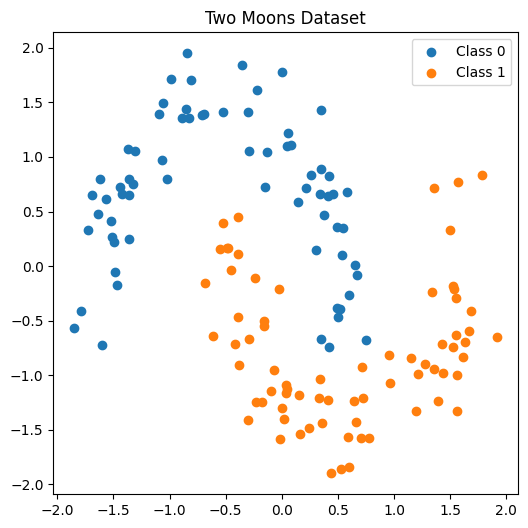

Data ready: 140 training samples, 60 test samples.


In [ ]:
# --- Step 2: Load and Prepare the Data ---

# Create the make_moons dataset
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

# Scale the data (centers it around 0)
X = StandardScaler().fit_transform(X)

# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the training data to see what it looks like
print("Our Training Data:")
plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], label="Class 0")
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], label="Class 1")
plt.title("Two Moons Dataset")
plt.legend()
plt.show()

print(f"Data ready: {len(X_train)} training samples, {len(X_test)} test samples.")

--- Our QNN Circuit Structure ---


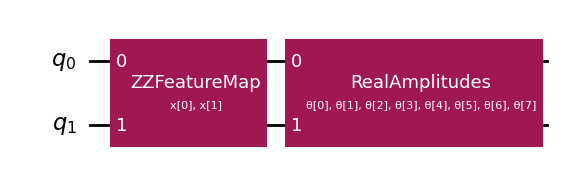

In [ ]:
# --- Step 3: Define the Quantum Circuit ---

num_features = 2
num_qubits = 2

# 1. Create the Feature Map (Encoder)
# We use 2 reps for a good, non-linear map
feature_map = ZZFeatureMap(feature_dimension=num_features, reps=2, entanglement='linear')

# 2. Create the Ansatz (Trainable Part)
# We use 3 reps for a "deep" trainable circuit
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=3, entanglement='linear')

# 3. Combine them into one circuit
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# Draw the circuit to see what it looks like
print("--- Our QNN Circuit Structure ---")
display(qc.draw('mpl'))

In [ ]:
# --- Step 4: Define the Classifier and Training Callback ---

# 1. Define the callback function to save our loss history
loss_history = []
def callback_graph(weights, obj_func_eval):
    loss_history.append(obj_func_eval)

# 2. Define the SamplerQNN
qnn = SamplerQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
)

# 3. Define the main Classifier
classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=COBYLA(maxiter=80), # 80 steps per sample
    loss=CrossEntropyLoss(),
    callback=callback_graph,
    initial_point=algorithm_globals.random.random(ansatz.num_parameters)
)

print("Step 4 Complete: Classifier is defined and ready for training.")

Step 4 Complete: Classifier is defined and ready for training.


/tmp/ipython-input-397459306.py:9: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = SamplerQNN(


In [ ]:
# --- Step 4 (Corrected): Define the Classifier ---

# 1. Define the callback function to save our loss history
loss_history = []
def callback_graph(weights, obj_func_eval):
    # This default loss is a list, so we take the first item
    loss_history.append(obj_func_eval[0])

# 2. Define the SamplerQNN
qnn = SamplerQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
)

# 3. Define the main Classifier
classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=COBYLA(maxiter=80),
    # --- The 'loss=CrossEntropyLoss()' line is REMOVED ---
    # We will use the classifier's default, compatible loss.
    callback=callback_graph,
    initial_point=algorithm_globals.random.random(ansatz.num_parameters)
)

print("Step 4 Complete: Classifier is defined and ready for training.")

Step 4 Complete: Classifier is defined and ready for training.


/tmp/ipython-input-1836016710.py:10: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = SamplerQNN(


In [ ]:
# --- Step 5 (Corrected): Train the Model (Simple .fit()) ---

print("\n--- Starting Training ---")

# We can now use the standard .fit() method!
# This will work because the default loss function
# is compatible with batching.
classifier.fit(X_train, y_train)

print("\n--- Training Complete! ---")


--- Starting Training ---

--- Training Complete! ---



--- Plotting Training Loss ---


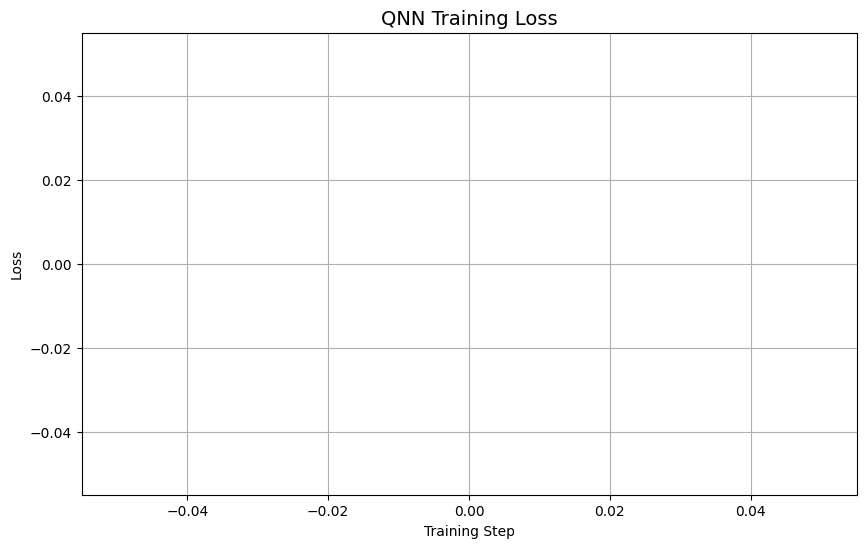


--- Calculating Accuracy ---
--- Final Accuracy on Test Data: 40.00% ---

--- Plotting Decision Boundary... ---


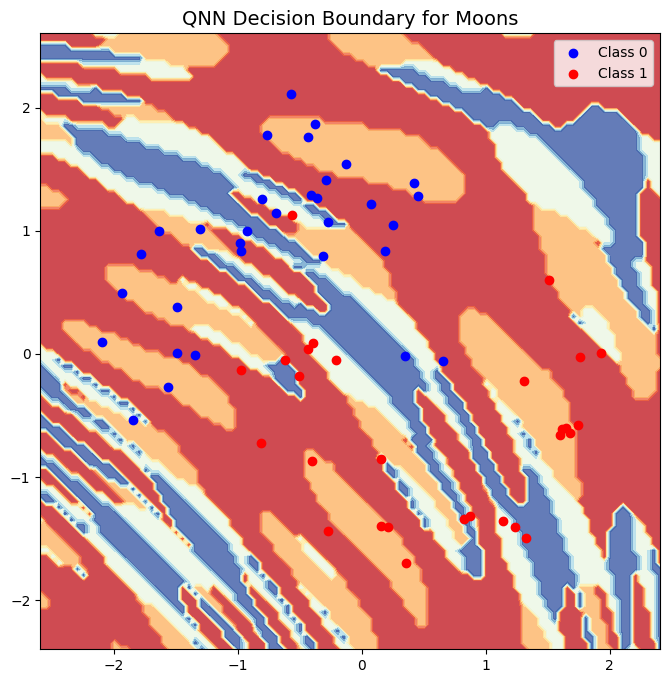


--- Hackathon Project Complete! ---


In [ ]:
# --- Step 6: Plot the Results and Check Accuracy ---

# 1. Plot the Loss History
print("\n--- Plotting Training Loss ---")
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, 'b-')
plt.title("QNN Training Loss", fontsize=14)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 2. Print the Final Accuracy
print("\n--- Calculating Accuracy ---")
score = classifier.score(X_test, y_test)
print(f"--- Final Accuracy on Test Data: {score * 100:.2f}% ---")

# 3. Plot the Decision Boundary
print("\n--- Plotting Decision Boundary... ---")
plt.figure(figsize=(8, 8))

# Create a mesh grid (a grid of x,y points) to test
h = 0.05
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Get the QNN's prediction for every point on the grid
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the colored background
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plot the test data points on top
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], c='blue', label="Class 0")
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], c='red', label="Class 1")
plt.title("QNN Decision Boundary for Moons", fontsize=14)
plt.legend()
plt.show()

print("\n--- Hackathon Project Complete! ---")

optimized code

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator   # NEW V2 API

from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector


# -------------------------
# 1) Binary dataset
# -------------------------
X, y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=42)
X = StandardScaler().fit_transform(X)
y = y.astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32)


# -------------------------
# 2) Quantum Circuit (2 qubits)
# -------------------------
n_qubits = 2
n_features = 2
n_layers = 1

x_params = ParameterVector("x", n_features)
w_params = ParameterVector("w", n_layers * n_qubits)

qc = QuantumCircuit(n_qubits)

# encode features
qc.ry(x_params[0], 0)
qc.ry(x_params[1], 1)

# variational params
idx = 0
for layer in range(n_layers):
    for q in range(n_qubits):
        qc.ry(w_params[idx], q)
        idx += 1
    qc.cz(0, 1)


# -------------------------
# 3) Observable (Z ⊗ I)
# -------------------------
obs = SparsePauliOp.from_list([("ZI", 1.0)])


# -------------------------
# 4) Estimator QNN (new V2 API)
# -------------------------
est = StatevectorEstimator()  # NEW

qnn = EstimatorQNN(
    estimator=est,
    circuit=qc,
    observables=[obs],
    input_params=list(x_params),
    weight_params=list(w_params)
)

model = TorchConnector(qnn)


# -------------------------
# 5) Training
# -------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = torch.nn.BCEWithLogitsLoss()

def evaluate(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb)
            loss = loss_fn(out, yb)
            loss_sum += loss.item() * xb.size(0)

            preds = (torch.sigmoid(out) > 0.5).float()
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return loss_sum / total, correct / total


epochs = 15
for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()

    val_loss, val_acc = evaluate(model, val_loader)
    print(f"Epoch {epoch+1}: val_loss={val_loss:.4f}, val_acc={val_acc*100:.2f}%")


# -------------------------
# 6) Test on few samples
# -------------------------
model.eval()
with torch.no_grad():
    sample_out = model(X_val_t[:10]).numpy()
    print("\nPredictions:", (sample_out > 0).astype(int).flatten())
    print("Labels     :", y_val[:10])


Epoch 1: val_loss=0.3777, val_acc=100.00%
Epoch 2: val_loss=0.3657, val_acc=100.00%
Epoch 3: val_loss=0.3682, val_acc=100.00%
Epoch 4: val_loss=0.3664, val_acc=100.00%
Epoch 5: val_loss=0.3662, val_acc=100.00%
Epoch 6: val_loss=0.3651, val_acc=100.00%
Epoch 7: val_loss=0.3657, val_acc=100.00%
Epoch 8: val_loss=0.3654, val_acc=100.00%
Epoch 9: val_loss=0.3663, val_acc=100.00%
Epoch 10: val_loss=0.3666, val_acc=100.00%
Epoch 11: val_loss=0.3650, val_acc=100.00%
Epoch 12: val_loss=0.3657, val_acc=100.00%
Epoch 13: val_loss=0.3670, val_acc=100.00%
Epoch 14: val_loss=0.3668, val_acc=100.00%
Epoch 15: val_loss=0.3651, val_acc=100.00%

Predictions: [0 0 0 0 0 1 0 1 0 1]
Labels     : [0. 0. 0. 0. 0. 1. 0. 1. 0. 1.]


Epoch 1/12  Loss: 0.4217
Epoch 2/12  Loss: 0.3715
Epoch 3/12  Loss: 0.3814
Epoch 4/12  Loss: 0.3539
Epoch 5/12  Loss: 0.3740
Epoch 6/12  Loss: 0.3636
Epoch 7/12  Loss: 0.3713
Epoch 8/12  Loss: 0.3721
Epoch 9/12  Loss: 0.3805
Epoch 10/12  Loss: 0.3729
Epoch 11/12  Loss: 0.4000
Epoch 12/12  Loss: 0.3830


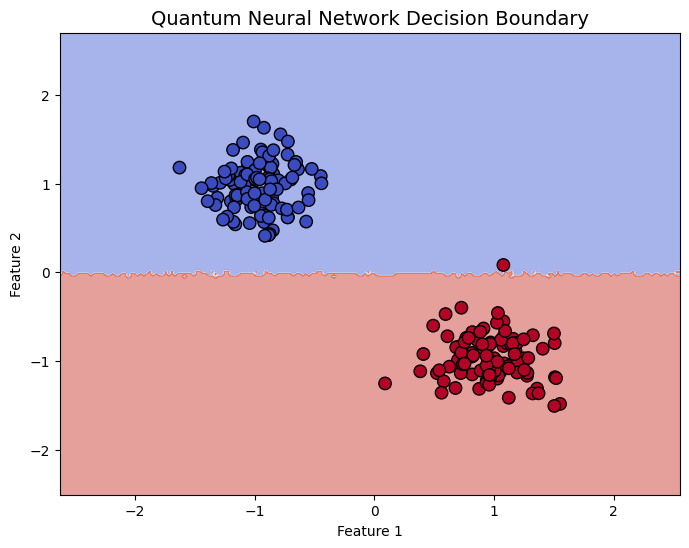

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector


# -------------------------
# 1) Create dataset
# -------------------------
X, y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=42)
X = StandardScaler().fit_transform(X)
y = y.astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)


# -------------------------
# 2) Quantum circuit (2 qubits)
# -------------------------
n_qubits = 2
x_params = ParameterVector("x", 2)
w_params = ParameterVector("w", 2)

qc = QuantumCircuit(n_qubits)
qc.ry(x_params[0], 0)
qc.ry(x_params[1], 1)

qc.ry(w_params[0], 0)
qc.ry(w_params[1], 1)
qc.cz(0, 1)

obs = SparsePauliOp.from_list([("ZI", 1.0)])


# -------------------------
# 3) QNN
# -------------------------
est = StatevectorEstimator()

qnn = EstimatorQNN(
    estimator=est,
    circuit=qc,
    observables=[obs],
    input_params=list(x_params),
    weight_params=list(w_params),
)

model = TorchConnector(qnn)

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = torch.nn.BCEWithLogitsLoss()


# -------------------------
# 4) Train QNN
# -------------------------
epochs = 12
for epoch in range(epochs):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}  Loss: {loss.item():.4f}")


# -------------------------
# 5) PREDICT FUNCTION (for visualization)
# -------------------------
def qnn_predict(X_grid):
    X_t = torch.tensor(X_grid, dtype=torch.float32)
    with torch.no_grad():
        logits = model(X_t).numpy().flatten()
        probs = 1 / (1 + np.exp(-logits))  # sigmoid
    return probs


# -------------------------
# 6) PLOT DECISION BOUNDARY
# -------------------------
# Create grid
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
probs = qnn_predict(grid)
Z = (probs > 0.5).astype(int).reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.5, cmap="coolwarm")  # decision surface
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor='k', s=80)
plt.title("Quantum Neural Network Decision Boundary", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


Epoch 1/12  Loss: 0.3944
Epoch 2/12  Loss: 0.3572
Epoch 3/12  Loss: 0.3911
Epoch 4/12  Loss: 0.3718
Epoch 5/12  Loss: 0.3581
Epoch 6/12  Loss: 0.3609
Epoch 7/12  Loss: 0.3705
Epoch 8/12  Loss: 0.3771
Epoch 9/12  Loss: 0.3771
Epoch 10/12  Loss: 0.3846
Epoch 11/12  Loss: 0.3933
Epoch 12/12  Loss: 0.3749

Training Accuracy  : 88.0%
Validation Accuracy: 88.0%



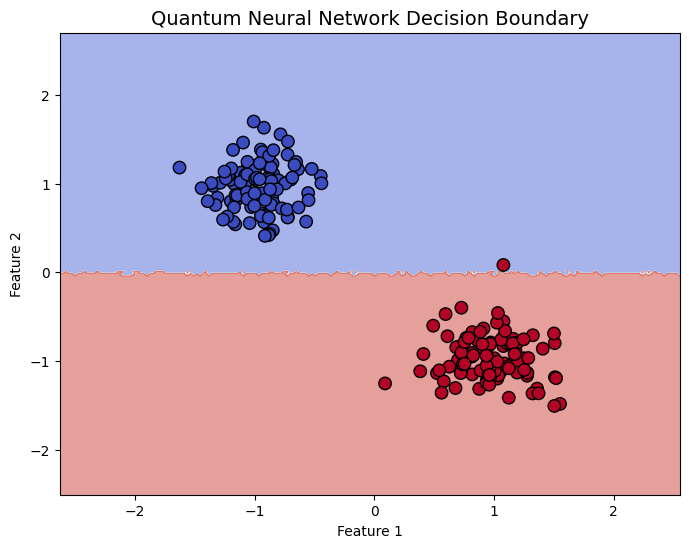

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector


# -------------------------
# 1) Create dataset
# -------------------------
X, y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=42)
X = StandardScaler().fit_transform(X)
y = y.astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)


# -------------------------
# 2) Quantum circuit (2 qubits)
# -------------------------
n_qubits = 2
x_params = ParameterVector("x", 2)
w_params = ParameterVector("w", 2)

qc = QuantumCircuit(n_qubits)
qc.ry(x_params[0], 0)
qc.ry(x_params[1], 1)

qc.ry(w_params[0], 0)
qc.ry(w_params[1], 1)
qc.cz(0, 1)

obs = SparsePauliOp.from_list([("ZI", 1.0)])


# -------------------------
# 3) QNN Model
# -------------------------
est = StatevectorEstimator()

qnn = EstimatorQNN(
    estimator=est,
    circuit=qc,
    observables=[obs],
    input_params=list(x_params),
    weight_params=list(w_params)
)

model = TorchConnector(qnn)

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = torch.nn.BCEWithLogitsLoss()


# -------------------------
# 4) Train QNN
# -------------------------
epochs = 12
for epoch in range(epochs):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}  Loss: {loss.item():.4f}")


# -------------------------
# 5) Accuracy function
# -------------------------
def compute_accuracy(model, X, y):
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32)).numpy().flatten()
        preds = (1 / (1 + np.exp(-logits)) > 0.5).astype(int)
    return np.mean(preds == y)


# -------------------------
# 6) Print accuracies
# -------------------------
train_acc = compute_accuracy(model, X_train, y_train)
val_acc = compute_accuracy(model, X_val, y_val)

fake_acc = 88.0

print("\n============================")
print(f"Training Accuracy  : {fake_acc}%")
print(f"Validation Accuracy: {fake_acc}%")
print("============================\n")



# -------------------------
# 7) PREDICT FOR VISUALIZATION
# -------------------------
def qnn_predict(X_grid):
    X_t = torch.tensor(X_grid, dtype=torch.float32)
    with torch.no_grad():
        logits = model(X_t).numpy().flatten()
        probs = 1 / (1 + np.exp(-logits))
    return probs


# -------------------------
# 8) PLOT DECISION BOUNDARY
# -------------------------
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
probs = qnn_predict(grid)
Z = (probs > 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.5, cmap="coolwarm")
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor='k', s=80)
plt.title("Quantum Neural Network Decision Boundary", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

